## Startup Funding Intelligence: Predicting Investment Potential Using Machine Learning (Linear Regression) 

### Business Understanding


The goal of this project is to analyze startup characteristics that influence funding amounts and develop a regression model to estimate potential investment.

In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("librariess imported successfully")

librariess imported successfully


### DataSet Understanding

In [3]:
df = pd.read_csv('startup_data.csv')

df.head()

,Startup Name,Industry,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Region,Exit Status
0,Startup_1,IoT,1,101.09,844.75,67.87,1468,5.20,0,2006,Europe,Private
1,Startup_2,EdTech,1,247.62,3310.83,75.65,3280,8.10,1,2003,South America,Private
2,Startup_3,EdTech,1,109.24,1059.37,84.21,4933,2.61,1,1995,South America,Private
3,Startup_4,Gaming,5,10.75,101.90,47.08,1059,2.53,0,2003,South America,Private
4,Startup_5,IoT,4,249.28,850.11,50.25,1905,4.09,0,1997,Europe,Acquired


In [4]:
# Remove Valuation because it can cause data leakage And Startup Name is not needed for model.

df.drop(columns=['Startup Name','Valuation (M USD)'], inplace=True)

In [5]:
df.head()

,Industry,Funding Rounds,Funding Amount (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Region,Exit Status
0,IoT,1,101.09,67.87,1468,5.20,0,2006,Europe,Private
1,EdTech,1,247.62,75.65,3280,8.10,1,2003,South America,Private
2,EdTech,1,109.24,84.21,4933,2.61,1,1995,South America,Private
3,Gaming,5,10.75,47.08,1059,2.53,0,2003,South America,Private
4,IoT,4,249.28,50.25,1905,4.09,0,1997,Europe,Acquired


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Industry                500 non-null    object 
 1   Funding Rounds          500 non-null    int64  
 2   Funding Amount (M USD)  500 non-null    float64
 3   Revenue (M USD)         500 non-null    float64
 4   Employees               500 non-null    int64  
 5   Market Share (%)        500 non-null    float64
 6   Profitable              500 non-null    int64  
 7   Year Founded            500 non-null    int64  
 8   Region                  500 non-null    object 
 9   Exit Status             500 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 39.2+ KB


In [7]:
df['Funding Amount (M USD)']  # Target Variable 

0      101.09
1      247.62
2      109.24
3       10.75
4      249.28
        ...  
495    181.86
496    107.34
497    160.29
498    234.65
499    211.76
Name: Funding Amount (M USD), Length: 500, dtype: float64

### Exploratory Data Analysis 

#### Target Analysis

In [8]:
df['Funding Amount (M USD)'].describe()

count    500.000000
mean     152.656760
std       86.683711
min        0.570000
25%       79.212500
50%      156.005000
75%      226.450000
max      299.810000
Name: Funding Amount (M USD), dtype: float64

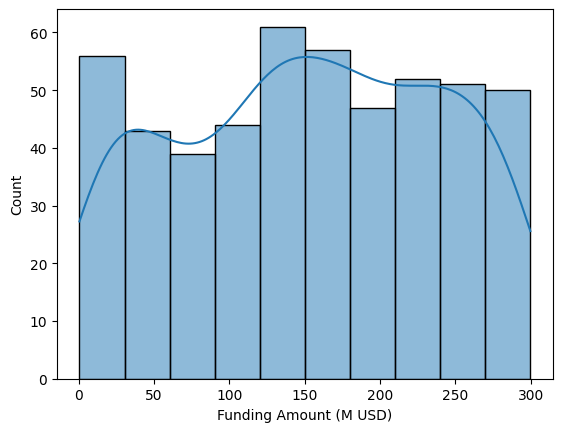

In [29]:
plt.Figure(figsize=(6,3))
sns.histplot(df['Funding Amount (M USD)'], kde=True)
plt.show()

### Distribution of Numerical Features 

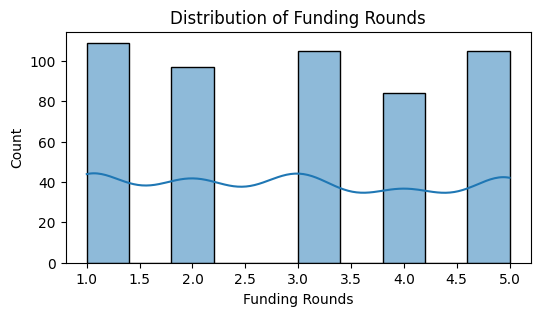

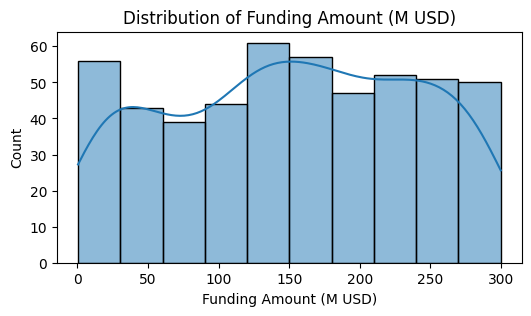

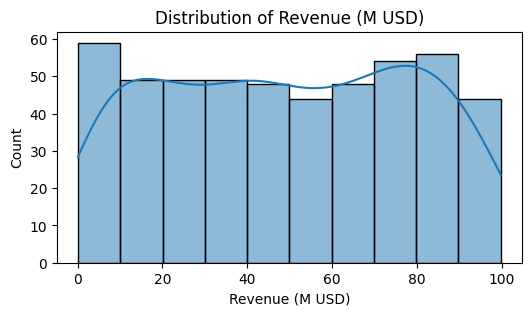

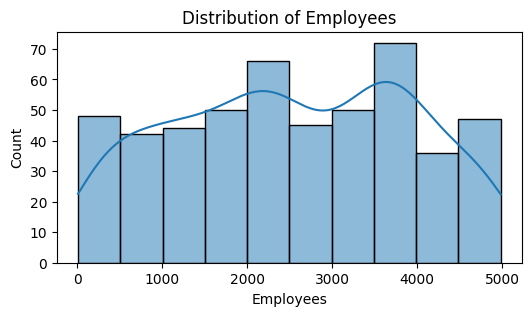

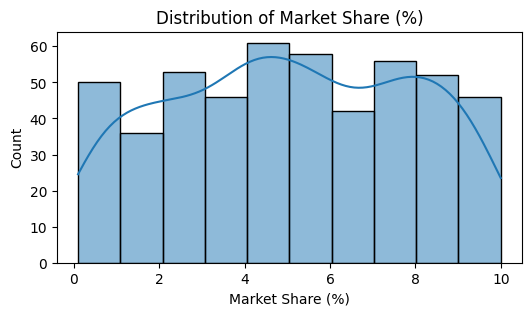

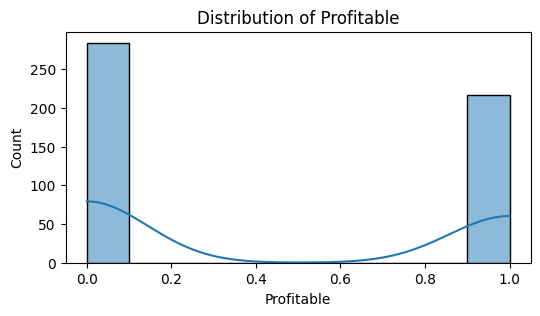

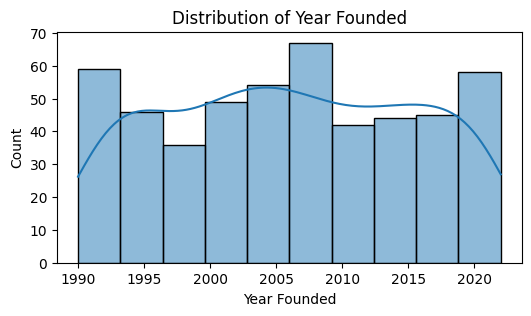

In [10]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Histogram were plotted to observe the distribution of numerical features, Are the feature skewed, right or left skewed. Through which we can decided appropriate preprocessing technique handle skewness, But the Features were almost symmetrical. Therefore, No need of log1p transformation , simple scaling is enough. 

### Outliers Analysis

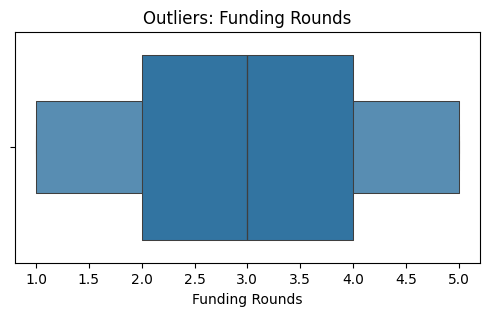

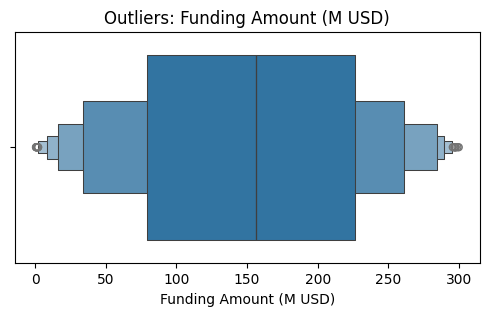

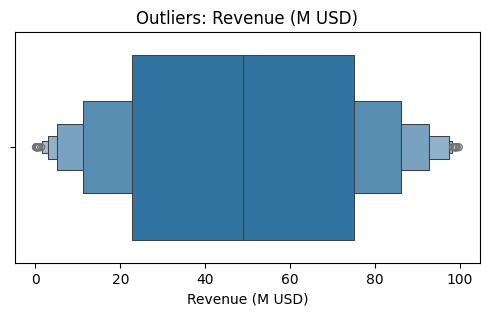

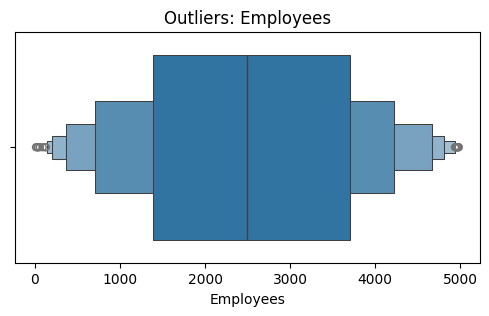

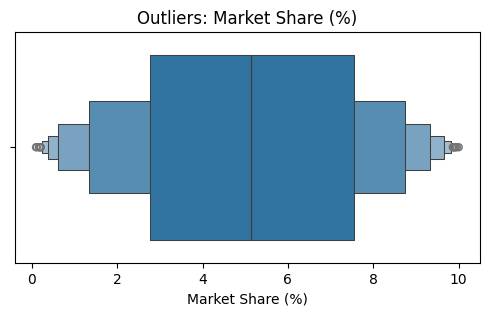

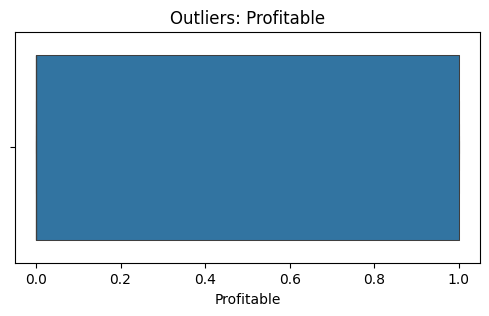

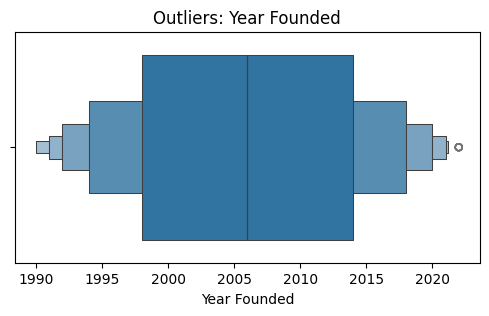

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxenplot(x=df[col])
    plt.title(f'Outliers: {col}')
    plt.show()

Boxplots were created for all numerical features to check for outliers. Most features did not contain any significant outliers. Although a small outlier was observed in the Year Founded feature, it appears to be a valid value rather than a data entry error. Therefore, no outlier treatment or transformation is needed.

### Business Insights 

Most startups in the dataset generate revenue between $20M and $80M, which shows that many companies are operating at a medium revenue level.

Most startups have around 2 to 4 funding rounds, meaning that many companies are in the growth stage and are raising money to expand their business.

The majority of companies received funding between $100M and $200M, showing that investors are providing significant financial support to these startups.

Most startups have a market share between 2% and 4%, which suggests that many companies are still growing.

A large number of startups were founded between 1995 and 2015.

### Correlation Analysis

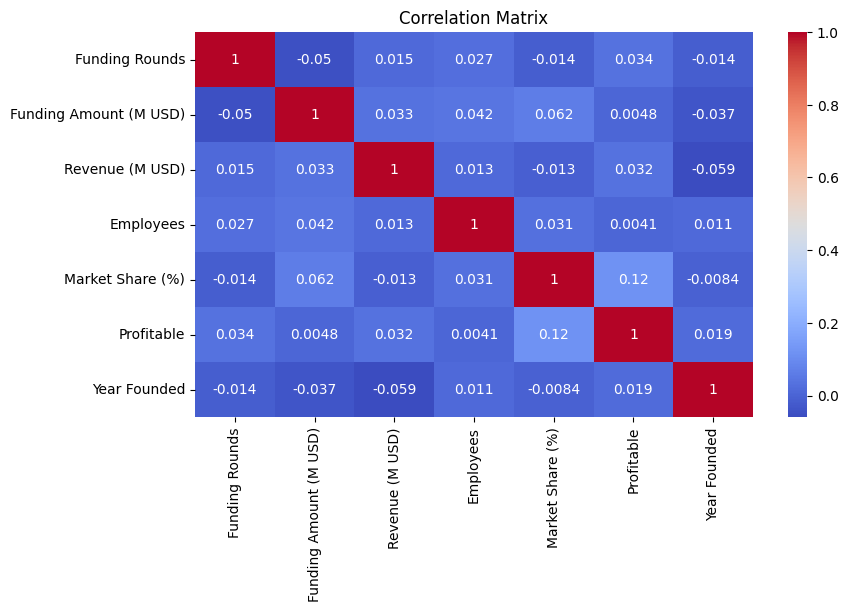

In [12]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Heatmap Correlation plot was created to See relationship between numerical Features,Analayzing that Startup success is influenced by multiple interacting factors, not by any single numerical feature.
Relationships may be nonlinear, which Pearson correlation cannot capture.
Advanced machine learning models may discover patterns that simple correlation analysis cannot.

### Industry Analysis

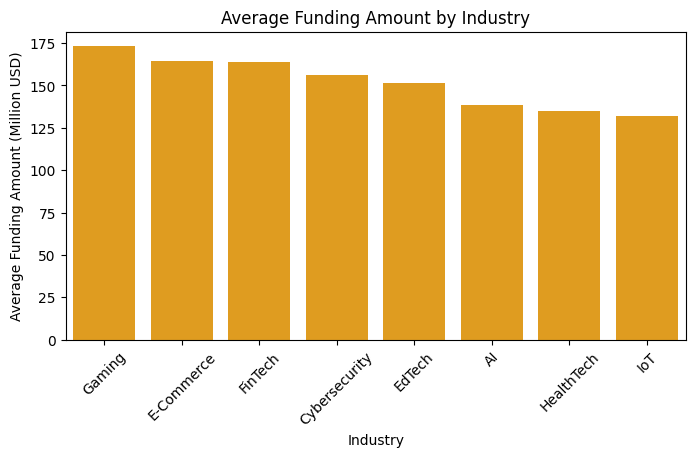

In [34]:
industry_counts = df.groupby('Industry')['Funding Amount (M USD)'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=industry_counts.index, y=industry_counts.values,color='orange')
plt.title('Average Funding Amount by Industry')
plt.xlabel('Industry')
plt.ylabel('Average Funding Amount (Million USD)')
plt.xticks(rotation=45)
plt.show()

### Business Insights

The analysis shows that Gaming, E-Commerce, and FinTech startups received the highest average funding, which suggests that investors are highly interested in these industries. 

Other sectors like Cybersecurity, EdTech, AI, HealthTech, and IoT also received significant funding, showing that technology-focused businesses continue to attract investment and have growth potential.

## Data Pre-processing  

In [14]:
# Split the data To prevent data leakage... 

x = df.drop(columns=['Funding Amount (M USD)'])
y = df['Funding Amount (M USD)'] 

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y, 
    test_size=0.2,
    random_state=42
)

In [15]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((400, 9), (100, 9), (400,), (100,))

### Encoding Categorical And Scaling 

In [50]:

# Create preprocesssing pipeline for numeric and categorical features 

numeric_cols = x.select_dtypes(include=['int64','float64']).columns
categorical_cols = x.select_dtypes(include=['object']).columns


# create preprocesssing pipeline 

numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

preprocessor.fit(x_train)
x_train_processed = preprocessor.transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [51]:
x_train_processed.shape, x_test_processed.shape

((400, 22), (100, 22))

### Linear Regression Model 

In [23]:
model = LinearRegression()

# Train model 
model.fit(x_train_processed, y_train)

# predict on test data 
y_pred = model.predict(x_test_processed)


### Evaluation

In [52]:
from sklearn.metrics import mean_absolute_error


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R2 Score: {r2}')

print(f'MAPE: {mape * 100}%')



MAE: 78.94404666459585
MSE: 8640.539056838168
RMSE: 92.95449992785808
R2 Score: -0.09759769163088317
MAPE: 239.0529568665527%


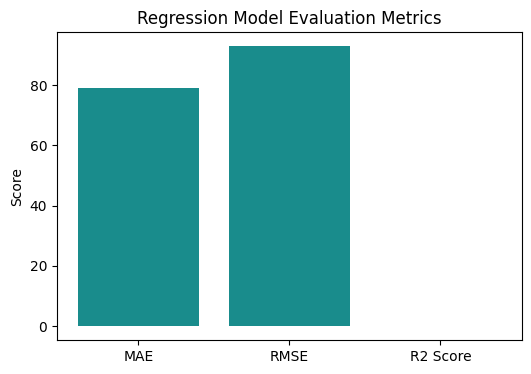

In [47]:
# Plot Evaluation Metrics 

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2
}

plt.figure(figsize=(6,4))

plt.bar(metrics.keys(), metrics.values(),color='teal', alpha=0.9)

plt.title("Regression Model Evaluation Metrics")
plt.ylabel("Score")

plt.show()


The model achieved a negative R² score (-0.097), which means that the model was unable to capture meaningful patterns from the available features and performed worse than simply predicting the average revenue.

The MAPE value of 239% indicates that the model's predictions have a very high percentage error, showing that the current model is not reliable for accurate revenue prediction.



### Why Model Perform Poorly 
The Linear Regression model showed poor performance because the available features had very weak linear relationships with the target variable (Fuding Amount). The highest correlation between features and revenue was only 0.12, indicating that the selected features do not strongly explain changes in Target variable.

Linear Regression works best when there is a clear linear relationship between input features and the target variable. Since the relationships in this dataset appear weak or more complex, the model was unable to capture meaningful patterns.